# Создание датасета из истории коммитов и его анализ

Практическая работа № 4 по дисциплине «Методы машинного обучения».
Московский Политех, группа 231-329, Арутюнян Ф. Р.

**Как я понял задачу.** Работа парная к лабораторной № 5, где датасет собирался из экспорта
переписки. Здесь источник другой: история моих git-репозиториев. Команда `git log` выдаёт
«сырой» текст, из него нужно собрать таблицу, очистить и проанализировать. Работа компактнее
лабораторной, упор на процесс сбора.

**Источник данных.** Локальные репозитории с учебными и личными проектами. Для каждого коммита
git хранит время, автора, сообщение и статистику изменённых файлов, поэтому история коммитов
это готовый журнал активности разработчика.

**Что собираю:** репозиторий, дата и время, час, день недели, автор, длина сообщения коммита,
число изменённых файлов, добавленные и удалённые строки.

**Приватность.** Часть репозиториев командные, поэтому имена авторов заменяются на псевдонимы
вида «Автор 03», а сообщения коммитов в датасет не попадают, сохраняется только их длина.

**План работы:**
1. Сбор сырого вывода `git log` из нескольких репозиториев.
2. Разбор вывода в таблицу и очистка.
3. Разведочный анализ с визуализацией.
4. Сохранение датасета в csv.
5. Демонстрация пригодности: модель отличает крупный коммит от мелкого.

## 0. Библиотеки и настройки

In [1]:
import os
import hashlib
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

FIG_DIR = 'figures'
os.makedirs(FIG_DIR, exist_ok=True)
RANDOM_STATE = 42


def save_fig(name):
    plt.savefig(os.path.join(FIG_DIR, name), dpi=150, bbox_inches='tight')

## 1. Сбор сырых данных

`git log` умеет печатать историю в заданном формате. Использую разделитель из редких символов,
чтобы поля не путались с текстом сообщения, и флаг `--numstat`, который после каждого коммита
печатает по строке на файл: добавлено, удалено, имя файла.

Формат вывода:

```
<хеш>|<дата ISO>|<автор>|<сообщение>
12	3	path/to/file.py
0	7	other/file.md
```

Слияния (`--no-merges`) пропускаю: у них нет собственных изменений, и они исказили бы статистику.

In [2]:
REPOS = {
    'Nexora': '~/Documents/personal/mospolytech/Nexora',
    'nexora-frontend': '~/Documents/personal/mospolytech/nexora-frontend',
    'hydrocalc': '~/Documents/personal/mospolytech/hydrocalc',
    'mmo': '~/Documents/personal/mospolytech/mmo',
    'fitness': '~/Documents/personal/fitness',
    'manifests': '~/Documents/personal/manifests-tmp',
}

SEP = '|~|'
FORMAT = f'%H{SEP}%aI{SEP}%an{SEP}%s'


def git_log(path):
    """Сырой вывод git log с построчной статистикой по файлам."""
    return subprocess.run(
        ['git', '-C', os.path.expanduser(path), 'log', '--no-merges',
         f'--pretty=format:{FORMAT}', '--numstat'],
        capture_output=True, text=True, check=True).stdout


raw = {}
for name, path in REPOS.items():
    if not os.path.isdir(os.path.expanduser(path) + '/.git'):
        print(f'{name}: репозитория нет, пропускаю')
        continue
    raw[name] = git_log(path)
    print(f'{name}: {len(raw[name].splitlines())} строк сырого вывода')

Nexora: 343 строк сырого вывода
nexora-frontend: 336 строк сырого вывода


hydrocalc: 288 строк сырого вывода


mmo: 191 строк сырого вывода


fitness: 1519 строк сырого вывода
manifests: 7472 строк сырого вывода


In [3]:
# в примере имена авторов заменены, чтобы не попадали в отчёт
sample = list(raw.values())[0].splitlines()[:8]
print('Пример сырого вывода (имена скрыты):')
for line in sample:
    if SEP in line:
        h, date, author, subject = line.split(SEP)
        line = SEP.join([h, date, '<автор>', subject])
    print(line)

Пример сырого вывода (имена скрыты):
e410e8d393a540294eef3e98aaf2358d372d6ece|~|2026-05-19T11:37:28+03:00|~|<автор>|~|fix: ruff unused arg
1	1	src/core/services/group.py

356af58b823da16db50523d6f70edca39076432a|~|2026-05-18T00:41:10+03:00|~|<автор>|~|fix: task update avoids lazy load crash (MissingGreenlet), explicit TaskStatusResponse construction
8	1	src/core/services/assignment.py

b95dd8877a6721de6e25596ce5e506b0902fdb32|~|2026-05-18T00:35:05+03:00|~|<автор>|~|fix: schedule import uses upsert (stable entry IDs across syncs, overrides survive re-import)
35	7	src/core/services/schedule.py


## 2. Разбор в таблицу

Вывод разбираю построчно: строка с разделителем начинает новый коммит, строки из трёх колонок
относятся к текущему коммиту. Бинарные файлы git помечает дефисами вместо чисел, такие строки
считаю как изменённый файл с нулём строк.

In [4]:
def parse(repo, text):
    commits, current = [], None
    for line in text.splitlines():
        if SEP in line:
            if current:
                commits.append(current)
            h, date, author, subject = line.split(SEP)
            current = {'repo': repo, 'hash': h[:8], 'datetime': date, 'author': author,
                       'subject_len': len(subject), 'files': 0, 'insertions': 0, 'deletions': 0}
        elif line.strip() and current is not None:
            parts = line.split('\t')
            if len(parts) == 3:
                add, rem, _ = parts
                current['files'] += 1
                current['insertions'] += int(add) if add.isdigit() else 0
                current['deletions'] += int(rem) if rem.isdigit() else 0
    if current:
        commits.append(current)
    return commits


rows = [c for repo, text in raw.items() for c in parse(repo, text)]
df = pd.DataFrame(rows)
print('Коммитов собрано:', len(df))
# имена авторов в выводе не показываю, псевдонимы появятся на следующем шаге
df.drop(columns=['author']).head(3)

Коммитов собрано: 1951


,repo,hash,datetime,subject_len,files,insertions,deletions
0,Nexora,e410e8d3,2026-05-19T11:37:28+03:00,20,1,1,1
1,Nexora,356af58b,2026-05-18T00:41:10+03:00,99,1,8,1
2,Nexora,b95dd887,2026-05-18T00:35:05+03:00,93,1,35,7


In [5]:
df['datetime'] = pd.to_datetime(df['datetime'], utc=True).dt.tz_convert('Europe/Moscow')
df['date'] = df['datetime'].dt.date
df['hour'] = df['datetime'].dt.hour
df['weekday'] = df['datetime'].dt.dayofweek
WEEKDAYS = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
df['weekday_name'] = df['weekday'].map(dict(enumerate(WEEKDAYS)))
df['month'] = df['datetime'].dt.to_period('M').astype(str)
df['changes'] = df['insertions'] + df['deletions']

# псевдонимы вместо имён авторов: репозитории командные
order = df['author'].value_counts().index
alias = {name: f'Автор {i + 1:02d}' for i, name in enumerate(order)}
df['author_hash'] = df['author'].apply(lambda s: hashlib.md5(str(s).encode()).hexdigest()[:8])
df['author'] = df['author'].map(alias)

print('Период:', df['date'].min(), '—', df['date'].max())
print('Репозиториев:', df['repo'].nunique(), '| авторов:', df['author'].nunique())
print('Пропуски:', int(df.isna().sum().sum()))
print('\nПо репозиториям:')
print(df['repo'].value_counts())

Период: 2024-09-03 — 2026-09-28
Репозиториев: 6 | авторов: 27
Пропуски: 0

По репозиториям:
repo
manifests          1661
fitness             153
Nexora               53
hydrocalc            40
nexora-frontend      39
mmo                   5
Name: count, dtype: int64


/var/folders/c2/l_fldtkj3cz5l1bmjq0nr7qc0000gp/T/ipykernel_27302/3552157620.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['month'] = df['datetime'].dt.to_period('M').astype(str)


### Очистка

Смотрю на аномалии. Коммиты без изменённых файлов бывают у пустых коммитов и у тех, где менялись
только права доступа. Огромные коммиты обычно это первый импорт проекта или загрузка библиотек
в репозиторий, они сильно искажают средние значения.

In [6]:
print('Коммитов без файлов:', int((df['files'] == 0).sum()))
print('Самый большой коммит:', int(df['changes'].max()), 'строк')
print(df['changes'].describe().round(1).to_dict())

q99 = df['changes'].quantile(0.99)
print(f'\n99-й процентиль изменений: {q99:.0f} строк')
big = df[df['changes'] > q99]
print('Коммитов крупнее:', len(big))
print(big[['repo', 'date', 'changes']].head(5).to_string(index=False))

before = len(df)
df = df[df['files'] > 0].copy()
print(f'\nПосле очистки: {len(df)} коммитов, удалено {before - len(df)}')

Коммитов без файлов: 2
Самый большой коммит: 133920 строк
{'count': 1951.0, 'mean': 237.9, 'std': 3688.4, 'min': 0.0, '25%': 2.0, '50%': 4.0, '75%': 27.5, 'max': 133920.0}

99-й процентиль изменений: 2322 строк
Коммитов крупнее: 20
           repo       date  changes
nexora-frontend 2026-04-13     2332
nexora-frontend 2026-03-02     8452
      hydrocalc 2025-01-14     9399
      hydrocalc 2025-01-14     2641
      hydrocalc 2025-01-14     2983

После очистки: 1949 коммитов, удалено 2


## 3. Разведочный анализ

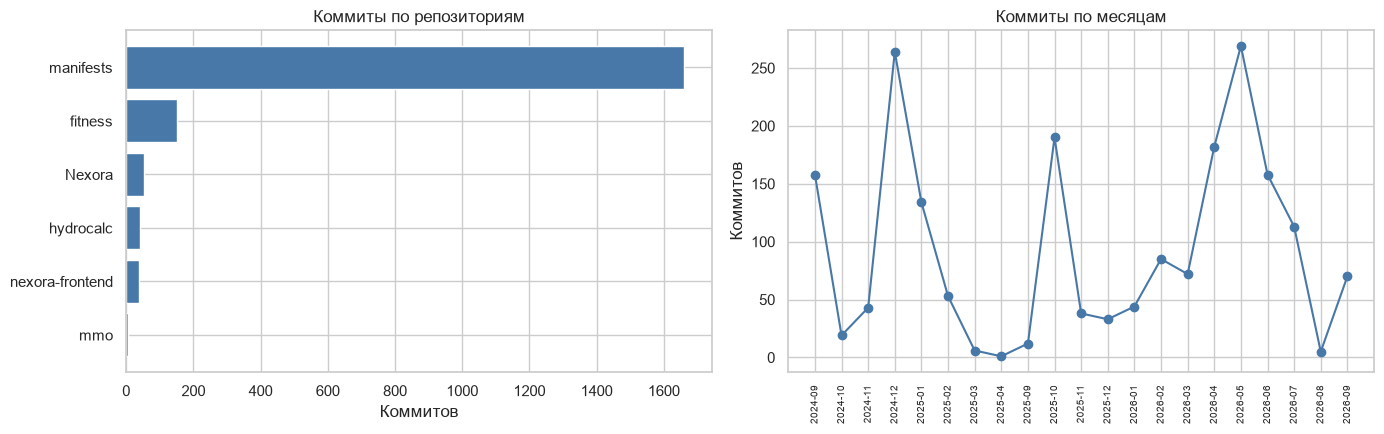

Активнее всего: manifests 1660 коммитов
Самый активный месяц: 2026-05 269


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
by_repo = df['repo'].value_counts()
axes[0].barh(by_repo.index[::-1], by_repo.values[::-1], color='#4878a8')
axes[0].set_xlabel('Коммитов')
axes[0].set_title('Коммиты по репозиториям')

by_month = df.groupby('month').size()
axes[1].plot(by_month.index, by_month.values, 'o-', color='#4878a8')
axes[1].set_ylabel('Коммитов')
axes[1].set_title('Коммиты по месяцам')
axes[1].tick_params(axis='x', rotation=90, labelsize=7)
fig.tight_layout()
save_fig('01_repos_months.png')
plt.show()

print('Активнее всего:', by_repo.idxmax(), int(by_repo.max()), 'коммитов')
print('Самый активный месяц:', by_month.idxmax(), int(by_month.max()))

**Рисунок 1 — Коммиты по репозиториям и по месяцам**

Больше всего коммитов в командном репозитории manifests (1660 из 1949), учебные проекты дают от 5 до 153 коммитов, а самый активный месяц май 2026 года (269 коммитов).

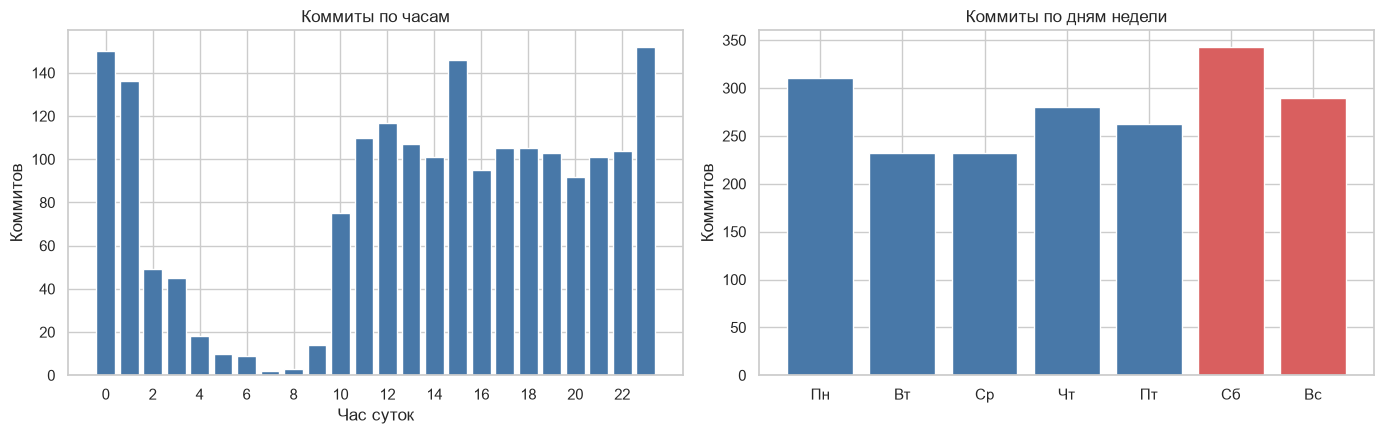

Пик: 23 часов
Ночью (0–6): 20.9% | в выходные: 32.5%


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
by_hour = df.groupby('hour').size().reindex(range(24), fill_value=0)
axes[0].bar(by_hour.index, by_hour.values, color='#4878a8')
axes[0].set_xlabel('Час суток')
axes[0].set_ylabel('Коммитов')
axes[0].set_title('Коммиты по часам')
axes[0].set_xticks(range(0, 24, 2))

by_wd = df.groupby('weekday').size()
axes[1].bar([WEEKDAYS[i] for i in by_wd.index], by_wd.values,
            color=['#4878a8'] * 5 + ['#d95f5f'] * 2)
axes[1].set_ylabel('Коммитов')
axes[1].set_title('Коммиты по дням недели')
fig.tight_layout()
save_fig('02_hour_weekday.png')
plt.show()

print('Пик:', int(by_hour.idxmax()), 'часов')
print('Ночью (0–6):', f"{df['hour'].between(0, 5).mean():.1%}",
      '| в выходные:', f"{(df['weekday'] >= 5).mean():.1%}")

**Рисунок 2 — Коммиты по часам и дням недели**

Пик коммитов в 23 часа, ночью с 0 до 6 часов сделано 20,9 % коммитов, в выходные 32,5 %, то есть разработка идёт в основном вне учебного времени.

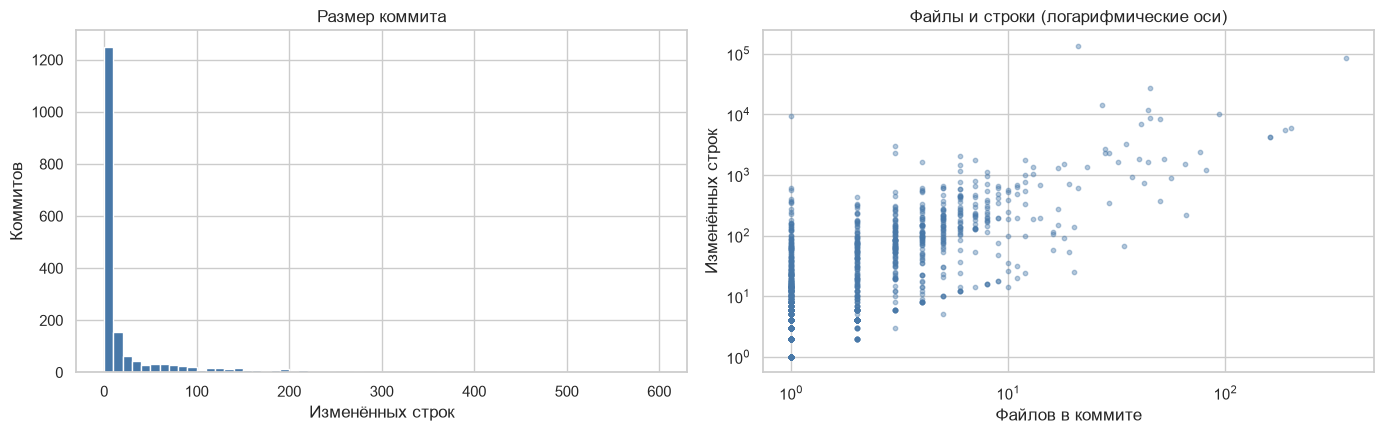

Медиана изменений: 4 строк, файлов: 1
Корреляция файлов и строк: 0.43


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].hist(df['changes'], bins=60, range=(0, 600), color='#4878a8', edgecolor='white')
axes[0].set_xlabel('Изменённых строк')
axes[0].set_ylabel('Коммитов')
axes[0].set_title('Размер коммита')

axes[1].scatter(df['files'], df['changes'], s=10, alpha=0.4, color='#4878a8')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Файлов в коммите')
axes[1].set_ylabel('Изменённых строк')
axes[1].set_title('Файлы и строки (логарифмические оси)')
fig.tight_layout()
save_fig('03_size.png')
plt.show()

print('Медиана изменений:', int(df['changes'].median()), 'строк, файлов:', int(df['files'].median()))
print('Корреляция файлов и строк:', round(df['files'].corr(df['changes']), 3))

**Рисунок 3 — Размер коммитов**

Большинство коммитов мелкие: медиана 4 изменённые строки в одном файле, а редкие огромные коммиты это первые импорты проектов, самый большой на 133 920 строк.

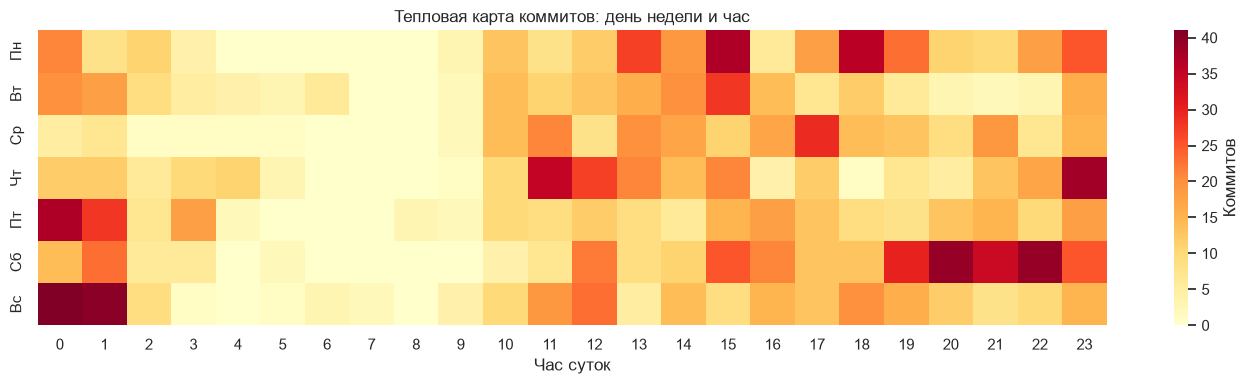

In [10]:
pivot = df.pivot_table(index='weekday', columns='hour', values='hash', aggfunc='count').fillna(0)
pivot = pivot.reindex(columns=range(24), fill_value=0)
pivot.index = [WEEKDAYS[i] for i in pivot.index]

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(pivot, cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Коммитов'})
ax.set_xlabel('Час суток')
ax.set_ylabel('')
ax.set_title('Тепловая карта коммитов: день недели и час')
fig.tight_layout()
save_fig('04_heatmap.png')
plt.show()

**Рисунок 4 — Тепловая карта коммитов**

Тепловая карта подтверждает вечерний и ночной ритм: яркие клетки идут поздним вечером и в выходные, а не в учебные часы.

## 4. Сохранение датасета

In [11]:
columns = ['repo', 'hash', 'datetime', 'date', 'hour', 'weekday', 'weekday_name', 'month',
           'author', 'author_hash', 'subject_len', 'files', 'insertions', 'deletions', 'changes']
dataset = df[columns].sort_values('datetime').reset_index(drop=True)
dataset.to_csv('data/commits.csv', index=False)
print('Строк:', len(dataset), '| столбцов:', dataset.shape[1],
      '| размер:', round(os.path.getsize('data/commits.csv') / 1024, 1), 'КБ')
dataset.head()

Строк: 1949 | столбцов: 15 | размер: 207.2 КБ


,repo,hash,datetime,date,hour,weekday,weekday_name,month,author,author_hash,subject_len,files,insertions,deletions,changes
0,manifests,d124675d,2024-09-03 15:10:18+03:00,2024-09-03,15,1,Вт,2024-09,Автор 18,e8790c3b,14,1,1,0,1
1,manifests,c937b140,2024-09-03 15:24:18+03:00,2024-09-03,15,1,Вт,2024-09,Автор 18,e8790c3b,32,1,76,0,76
2,manifests,dda30e32,2024-09-03 15:35:26+03:00,2024-09-03,15,1,Вт,2024-09,Автор 04,f843be85,51,1,1,1,2
3,manifests,0fa488ad,2024-09-03 15:44:04+03:00,2024-09-03,15,1,Вт,2024-09,Автор 18,e8790c3b,32,1,1,1,2
4,manifests,487d19bc,2024-09-03 15:47:39+03:00,2024-09-03,15,1,Вт,2024-09,Автор 04,f843be85,51,1,1,1,2


## 5. Демонстрация пригодности датасета

Задача: отличить крупный коммит от мелкого по признакам, не связанным напрямую с объёмом правок.
Крупным считаю коммит, у которого изменений больше медианы. Признаки: час, день недели,
длина сообщения коммита и репозиторий в виде числового кода.

Гипотеза простая: длинное сообщение коммита обычно сопровождает крупную правку,
а быстрые вечерние коммиты чаще мелкие.

In [12]:
median_changes = dataset['changes'].median()
data = dataset.copy()
data['is_big'] = (data['changes'] > median_changes).astype(int)
data['repo_code'] = data['repo'].astype('category').cat.codes

features = ['hour', 'weekday', 'subject_len', 'repo_code']
X, y = data[features], data['is_big']
print(f'Порог крупного коммита: {median_changes:.0f} строк, крупных {y.mean():.1%}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

scaler = StandardScaler().fit(X_train)
logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE).fit(scaler.transform(X_train), y_train)
rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                            random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train)

rows = []
for name, model, Xte in [('Логистическая регрессия', logreg, scaler.transform(X_test)),
                         ('Случайный лес', rf, X_test)]:
    proba = model.predict_proba(Xte)[:, 1]
    rows.append({'Модель': name,
                 'Accuracy': accuracy_score(y_test, (proba > 0.5).astype(int)),
                 'ROC-AUC': roc_auc_score(y_test, proba)})
results = pd.DataFrame(rows).set_index('Модель')
print()
print(results.round(4))
print()
print(classification_report(y_test, rf.predict(X_test), target_names=['мелкий', 'крупный'], digits=4))

Порог крупного коммита: 4 строк, крупных 44.3%



                         Accuracy  ROC-AUC
Модель                                    
Логистическая регрессия    0.6516   0.6486
Случайный лес              0.7152   0.7882

              precision    recall  f1-score   support

      мелкий     0.7098    0.8272    0.7640       272
     крупный     0.7251    0.5741    0.6408       216

    accuracy                         0.7152       488
   macro avg     0.7175    0.7006    0.7024       488
weighted avg     0.7166    0.7152    0.7095       488



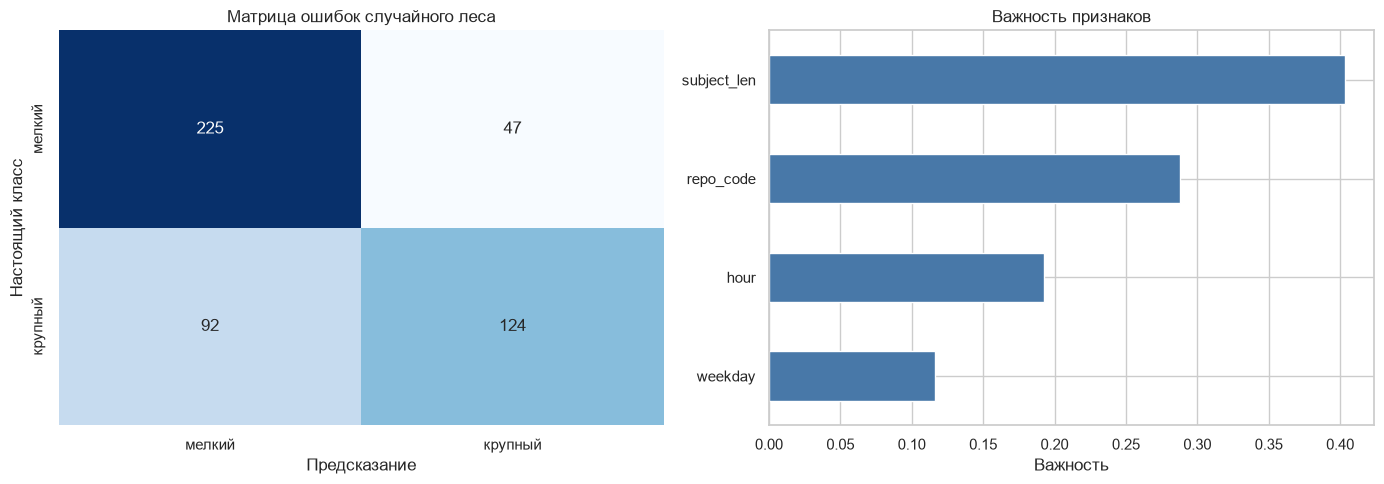

{'subject_len': 0.404, 'repo_code': 0.288, 'hour': 0.192, 'weekday': 0.117}


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_test, rf.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['мелкий', 'крупный'], yticklabels=['мелкий', 'крупный'], ax=axes[0])
axes[0].set_xlabel('Предсказание')
axes[0].set_ylabel('Настоящий класс')
axes[0].set_title('Матрица ошибок случайного леса')

imp = pd.Series(rf.feature_importances_, index=features).sort_values()
imp.plot.barh(ax=axes[1], color='#4878a8')
axes[1].set_xlabel('Важность')
axes[1].set_title('Важность признаков')
fig.tight_layout()
save_fig('05_model.png')
plt.show()

print(imp.sort_values(ascending=False).round(3).to_dict())

**Рисунок 5 — Определение крупного коммита: матрица ошибок и важность признаков**

Лес отличает крупный коммит от мелкого с точностью 0,7152 и ROC-AUC 0,7882, опираясь в первую очередь на длину сообщения коммита (0,404) и репозиторий (0,288).

## 6. Выводы

1. **Сбор.** Из шести локальных репозиториев командой `git log --numstat` собран сырой текст,
   разобран в таблицу из 1951 коммита. Очистка убрала 2 коммита без изменённых файлов,
   осталось 1949 коммитов за период с сентября 2024 по сентябрь 2026 года от 27 авторов.

2. **Датасет.** 15 столбцов: репозиторий, хеш, время, час, день недели, месяц, псевдоним и хеш
   автора, длина сообщения, число файлов, добавленные, удалённые и все изменённые строки.
   Файл `data/commits.csv` 207 КБ, настоящих имён и текстов коммитов в нём нет.

3. **Что показал анализ.** Активность неравномерна по репозиториям: командный manifests даёт
   85 % коммитов. Разработка идёт вечером и ночью: пик в 23 часа, 20,9 % коммитов ночью,
   32,5 % в выходные. Типичный коммит маленький, медиана 4 строки в одном файле, но распределение
   с очень длинным хвостом: первые импорты проектов достигают 133 920 строк.

4. **Пригодность для обучения.** По часу, дню недели, репозиторию и длине сообщения случайный лес
   отличает крупный коммит от мелкого с accuracy 0,7152 и ROC-AUC 0,7882, логистическая регрессия
   хуже (0,6516). Главный признак длина сообщения коммита (важность 0,404): крупную правку
   описывают подробнее.

5. **Сравнение с лабораторной № 5.** Оба датасета это журналы активности с похожей структурой:
   время, автор, свойства события. Отличие в ритме: чат группы живёт по учебному расписанию
   с пиком в 10 утра, коммиты делаются вечером и ночью с пиком в 23 часа.